# DOCKER

> Conceptos

Conceptos básicos de Docker

* Imagen → Plantilla lista para ejecutar (ej: python:3.10).

* Contenedor → Ejecución en vivo de la imagen.

* Dockerfile → Archivo donde escribes cómo construir tu propia imagen.

* Volumen → Carpeta compartida entre tu PC y el contenedor.

* Red → Forma en que los contenedores se comunican entre sí.

***Ejemplo***

La solución: Docker

* Docker permite empaquetar tu aplicación junto con todo lo necesario para ejecutarla en una imagen.

* Una imagen = receta (como una foto congelada de un sistema operativo + tus dependencias).

* Un contenedor = ejecución en vivo de esa imagen (como una “instancia” de esa foto).

Ejemplo mental:

* Imagen = receta de un pastel 🍰.

* Contenedor = el pastel ya horneado y servido 🎂.

* Puedes hacer muchos pasteles (contenedores) a partir de la misma receta (imagen).

Abrir docker desktop

> pruebas docker para verificar instalacion

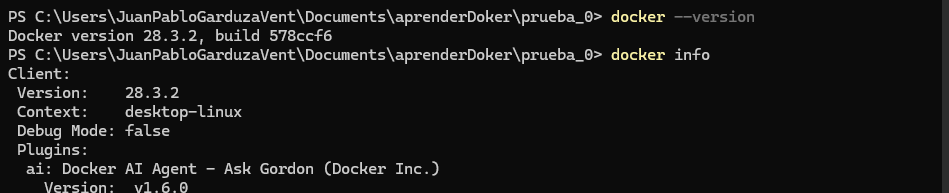

> ejecutar python dentro de un contenedor

* docker run → crea y ejecuta un contenedor.

* -it → modo interactivo con terminal.

* python:3.10 → es la imagen oficial de Python 3.10 (si no la tienes, se descarga).

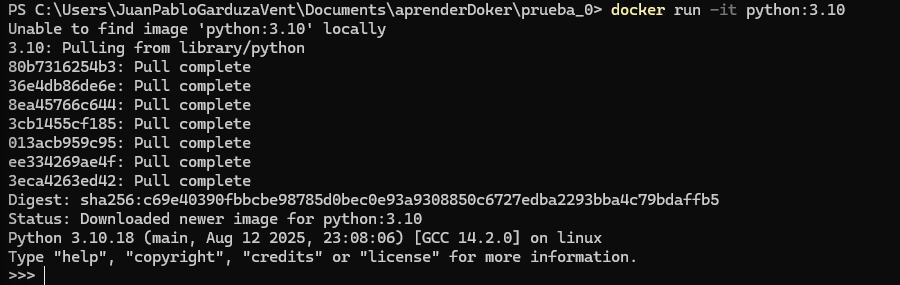

> Ver los contenedores en ejecución (incluso los que ya se detuvieron):

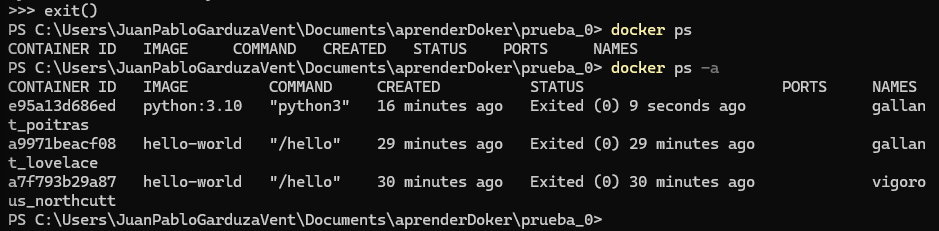

> Detener contenedor

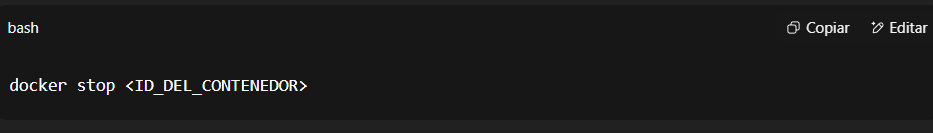

> *RESUMEN*

* Docker
    * Tecnologia que permite empaquetar aplicacion junto con todo lo necesario (librerias, dependcias, sistema base) para que funione igual, sin importar la maquina que se ejecute.

* Imagen 
    * Es como una receta congelada
    * Define que sistema base, que dependencias y que configuraciones tendra la app
    * No se ejecuta por si sola, es solo el "molde"
    * Ejemplo: python:3.10, mysql:8, nginx.

* Contenedor
    * Instacia en vivo de la imagen
    * aqui se ejecuta la app
    * puedes levantar muchos contenedores apaor de la misma imagen.
    * Ejemplo: tienes la imagen python:3.10, y corres 3 contenedores con distintos scripts.

* Pipeline (jenkins + Docker)
    1. Descarga codigo
    2. Ejecuta pytest en un contenedor
    3. Construir imagenfinal
    4. Desplegar al otro servidor

> Practica

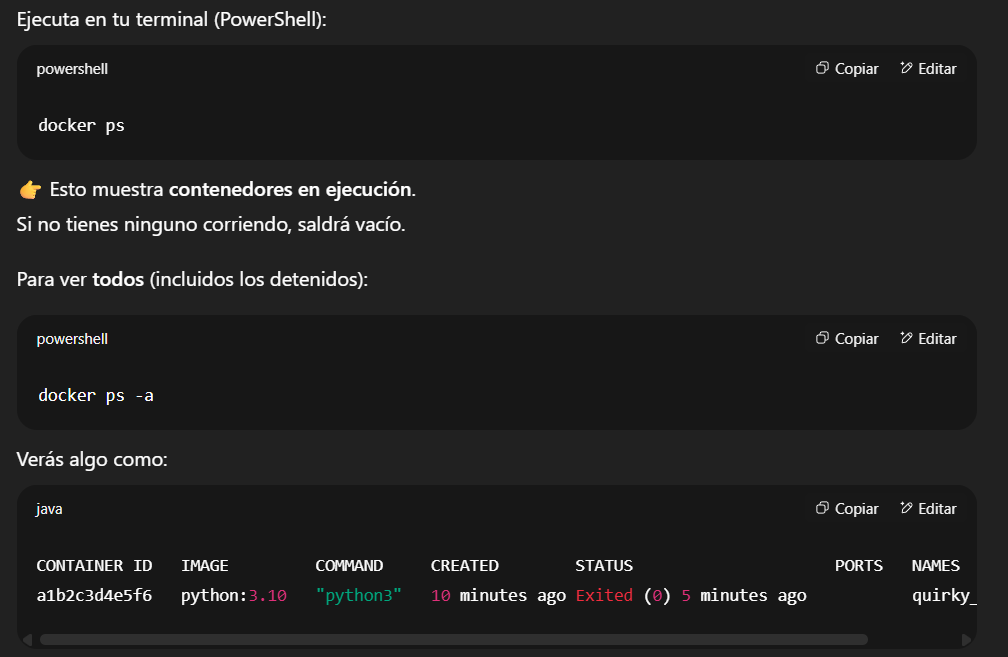

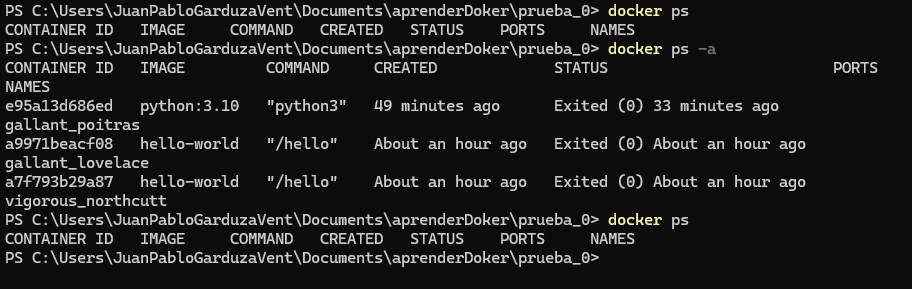

*DETENER*

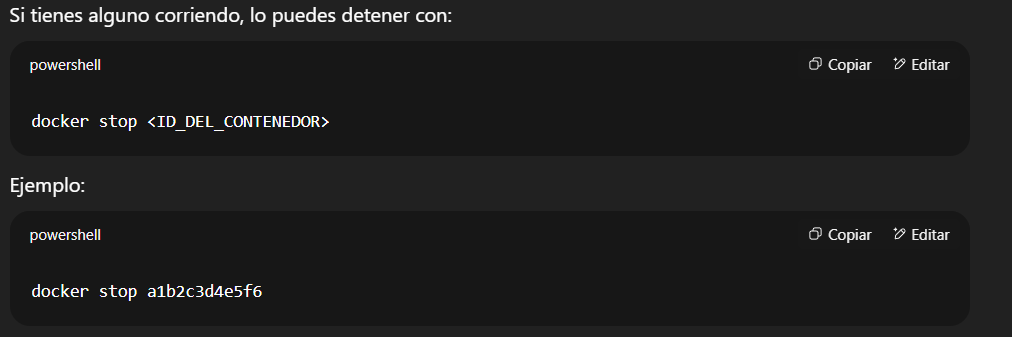

*ELIMINAR CONTENEDOR*

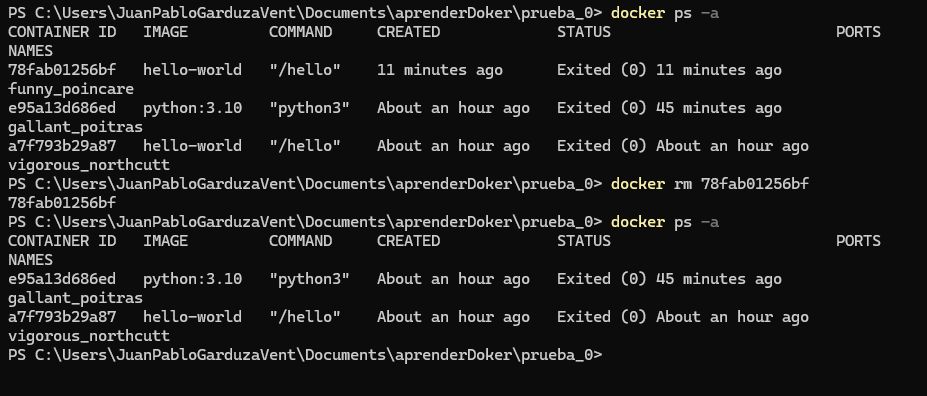

*ELIMINAR TODOS*

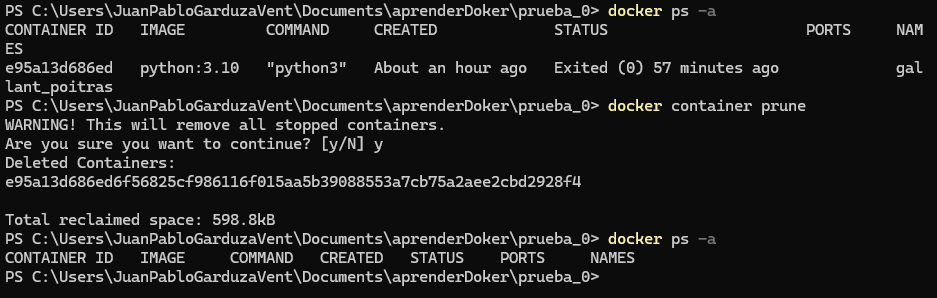

*Docker images*

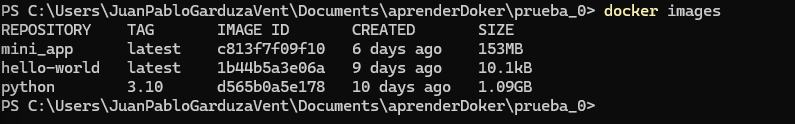

*ELIMINAR IMAGENES*

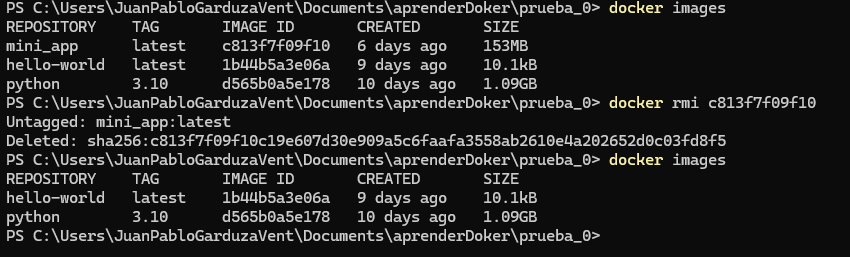

*ELIMINAR TODAS LAS IMAGENES*

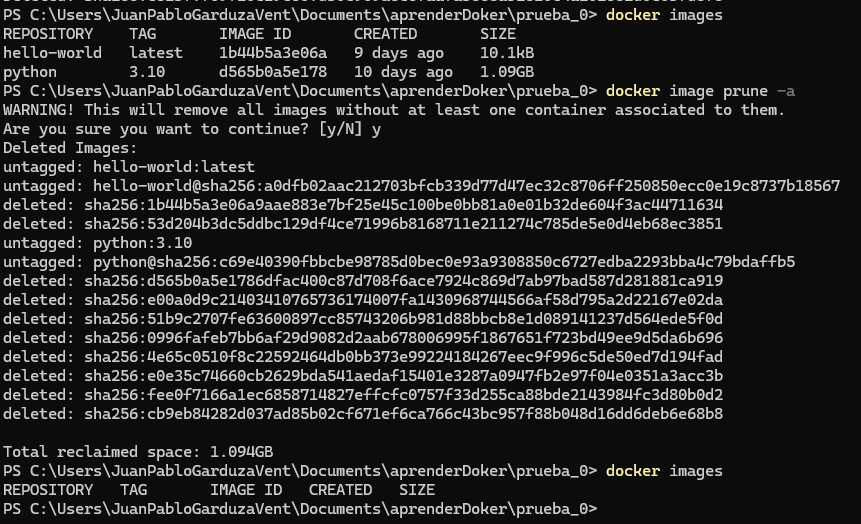

> DOCKER FILE

Es un archivo de texto (sin extencion, se llama Dockerfile) que contiene instrucciones para construir una imagen personalizada.

*Receta automatica:*

* Tú escribes los pasos.

* Docker los ejecuta uno por uno y genera una imagen.

* Luego, esa imagen la puedes ejecutar con docker run.

> *NOTA* 

* Si deceas agregar un cambio al docker file, cuando ya se aplico el build y run, se deben reconstruir la imagen

* Esa imagen puede usarse para crear uno o varios contenedores

* Puedes tener Dockerfile.paso1, Dockerfile.paso2, etc (para usalros indicar cual):
    * docker build -t imagen_paso1 -f Dockerfile.paso1 .
    * docker build -t imagen_paso2 -f Dockerfile.paso2 .

* se puede heredar imagenes creadas a otro:
    * FROM -> From prubea2:1:0
    

> Ejemplos 

1. Base y mensaje inicial 

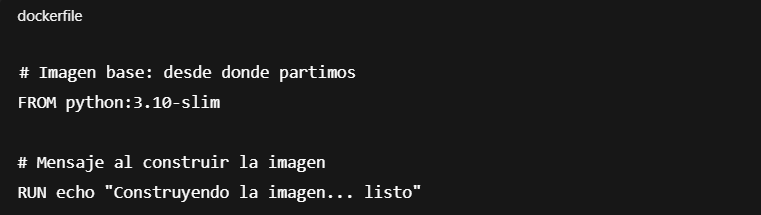

FROM → define la base de la imagen (Python 3.10 en este caso).

RUN echo ... → se ejecuta durante la construcción, el mensaje aparece en la terminal mientras haces docker build.

CMD → instrucción que se ejecuta cuando el contenedor arranca.


In [ ]:
# Imagen base: desde donde partimos
FROM python:3.10-slim

# Mensaje al construir la imagen
RUN echo "Construyendo la imagen... listo - RUN" 

#instrucción que se ejecuta cuando el contenedor arranca.
CMD ["echo", "Hola desde Docker -  CMD"]

*Prueba*

* docker build -t prueba1:1.0 .

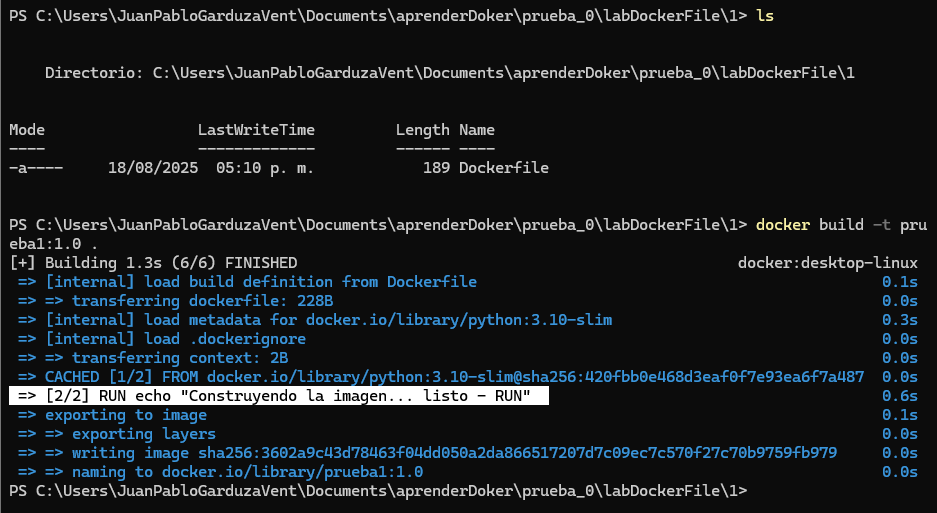

* docker run --rm prueba1:1.0

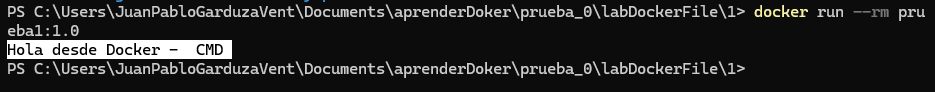

2. Crear directorios y archivos

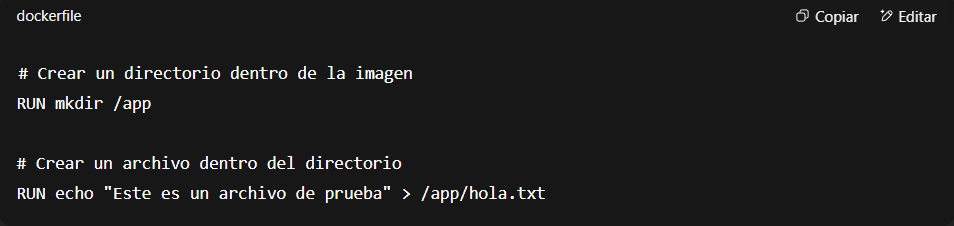



In [ ]:
# Imagen base (puede ser cualquier Linux ligero como Alpine o Debian)
# OBLIGATORIOOOO
FROM alpine:latest


# Crea un directorio dentro de la imagen
RUN mkdir /app

# Crea un archivo dentro del directorio
RUN echo "Esto es una archivo prueba" > /app/hola.txt


#soli se colocab muchos cmd, solo toma el ultimo
# Ejecuta varios comandos al iniciar el contenedor
CMD [ "sh", "-c", "ls /app && echo 'vamos a ver que trae el hola.txt' && cat /app/hola.txt" ]

*LO QUE SUCEDE O LOS COMANDOS QUE SUCEDEN, SON DENTRO DEL CONTENEDOR, NO DE MANERA LOCAL*

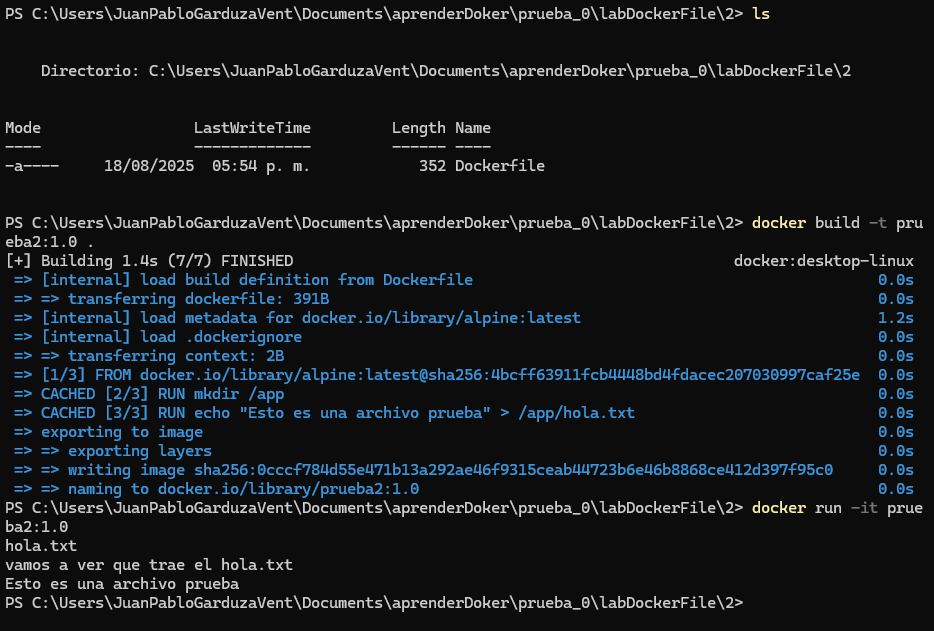

3. Copy


In [ ]:
FROM alpine:latest

# Crear directorio
RUN mkdir /app

############# EJEMPLO 3

# Copiar holaMundo.py al contenedor
COPY holaMundo.py /app/holaMundo.py

# Comando que se ejecuta al iniciar el contenedor
CMD ["sh","-c","ls /app && cat /app/holaMundo.py"]


Como vemos, se crea el dir, y copia a la vez el archivo al nuevo dir, al ejecutar checa los comandos ls y cat

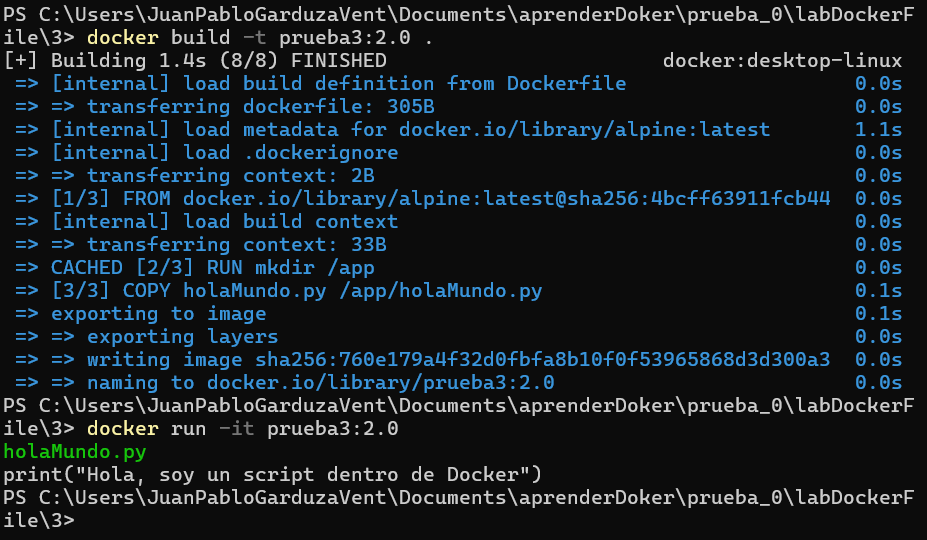

4. Herencia de imagen

In [ ]:
# En lugar de alpine, usa tu imagen ya creada
FROM prueba2:2.0  

# Ahora sí, construyes sobre lo que ya trae /app/hola.txt
COPY holaMundo.py /app/holaMundo.py

CMD ["sh", "-c", "ls /app && cat /app/holaMundo.py"]


Como vemos, tomamos imagen donde de ahi parte, mas no desde 0

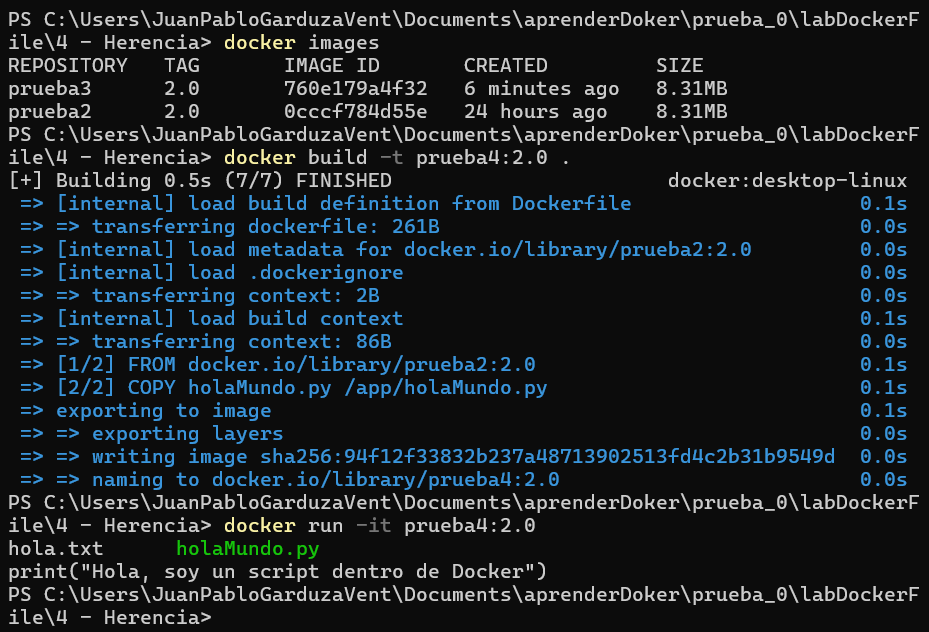

5. Entrar a contennedor 

a. 

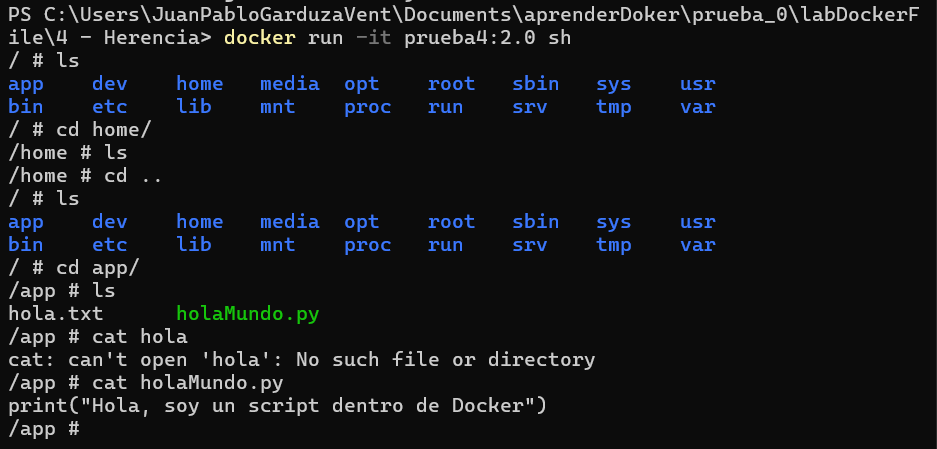

verificamos que este en ejecucion

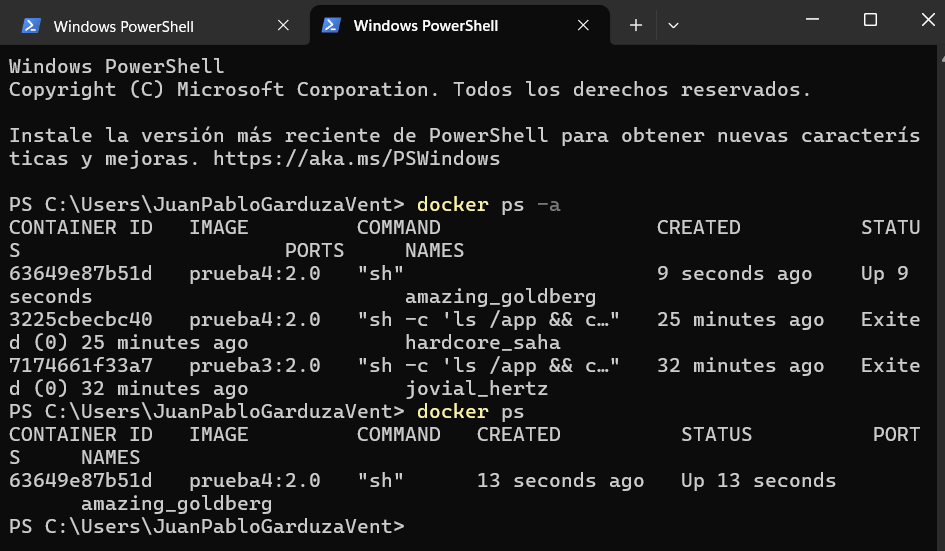

*NOTA*

* Cuando sales del contenedor (exit) y no lo guardaste, los cambios se pierden.

* Si quieres guardar cambios en una nueva imagen:
    * docker commit <container_id> prueba3_modificada:1.0
        * Ahora tienes una nueva imagen con los cambios que hiciste dentro del contenedor.


b. haces otro Dockerfile que parte de tu imagen existente y aplicas cambios:



In [ ]:
FROM prueba3:2.0

# Crear un nuevo directorio
RUN mkdir /app/nuevo_dir

# Agregar un nuevo script
COPY nuevo.py /app/nuevo_dir/nuevo.py

# CMD final
CMD ["sh","-c","ls /app && ls /app/nuevo_dir && cat /app/holaMundo.py"]


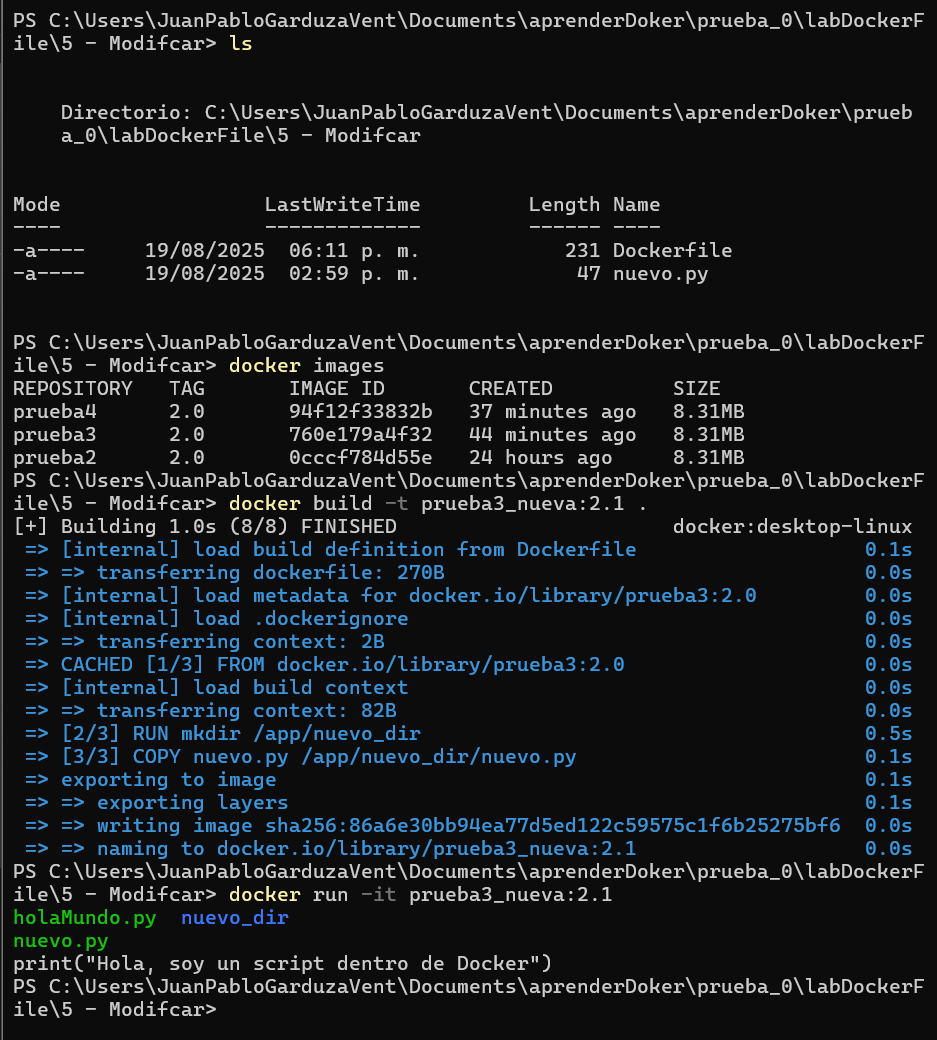

vemos 

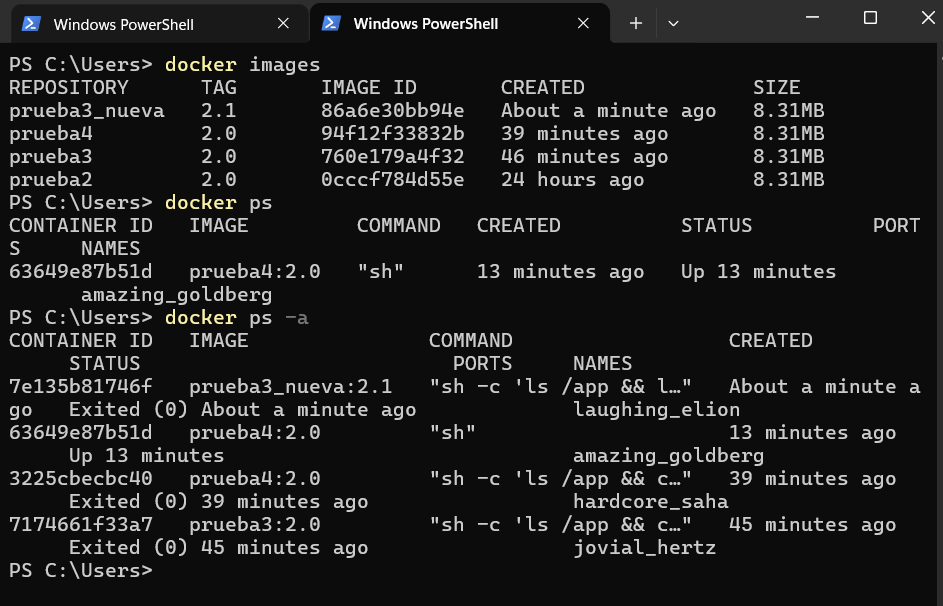

*NOTA GENERAL*

- docker run -it prueba3:1.0 sh
    - Lo que haces solo afecta ese contenedor en vivo.
    - Si creas archivos, modificas scripts o carpetas, los cambios existen mientras el contenedor esté vivo.
    - Si matas el contenedor (exit o docker stop), los cambios desaparecen, porque no modificaste la imagen original.
    - Si quieres guardar cambios en una nueva imagen: docker commit <container_id> prueba3_modificada:1.0
    - Luego puedes correr un nuevo contenedor a partir de esa imagen: docker run -it prueba3_modificada:1.0
- Con FROM en un Dockerfile
    - creas una nueva imagen heredando todo lo que ya tenía la imagen base. Es declarativo, reproducible y fácil de versionar.

6. CMD

In [ ]:
FROM prueba3:2.0

RUN apk update && apk add --no-cache python3 py3-pip

CMD ["python3", "/app/holaMundo.py"]

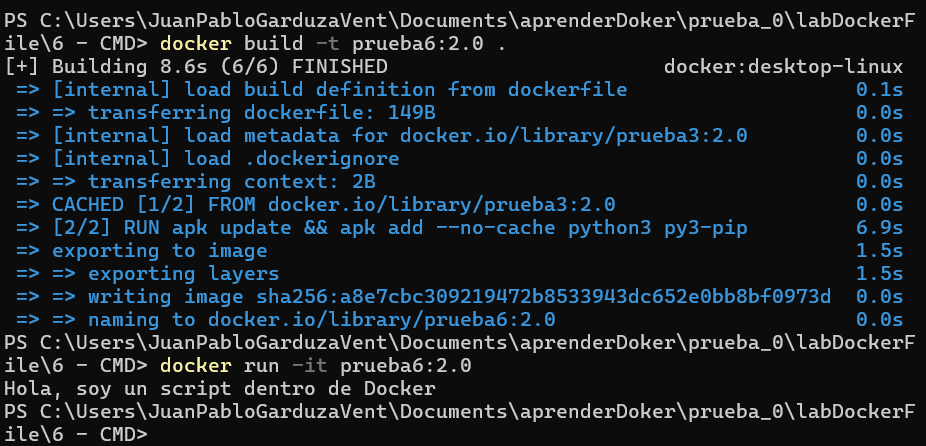

7. Volumenes

*Conceptos:*

* Espacio de almacenamiento persistente:
    * Es un directorio que Docker administra especialmente para que los datos no se pierdan cuando borras un contenedor.
    * Puede estar dentro del contenedor, pero Docker lo guarda fuera de la capa de la imagen, en un área especial de tu máquina.
* Tipos: 
    * Volumen anónimo
        * Persiste aunque borres el contenedor, pero no sabes exactamente dónde está en tu PC.
        * Docker crea un directorio en su almacenamiento interno (/var/lib/docker/volumes/...).
        * Útil si solo quieres que los datos sobrevivan a contenedores temporales.
    * Volumen mapeado a tu máquina (-v host_path:container_path)
        * Se mapea a una carpeta concreta en tu disco.
        * Ideal para desarrollo o intercambio de archivos entre contenedores y tu PC.
* Volúmenes y contenedores múltiples
    * Sí, dos contenedores pueden usar el mismo volumen.
    * Esto permite compartir datos entre contenedores (por ejemplo, dos apps accediendo a los mismos logs o bases de datos).

> TEMAS A BUSCAR

* enlazar contenedores

* workdir - dorckerfile ---Docker crea /app si no existe
WORKDIR /app
WORKDIR src

Esto te lleva a /app/src, y Docker crea ambos si no existen.

* comandos de que se ejecutan durante la construccion de imagen:
    * from, run, copy, add, workdir, env, label

* comandos de que se ejecutan al iniciar el contenedor:
    * cmd, entrypoint, healthchec, expose,volume

* ENTRYPOINT vs CMD (cómo y cuándo se sobreescriben)

* jenkins los necesarios
    
